In [1]:
import pandas as pd
import numpy as np
import re                  #regularexpression
import nltk
import matplotlib.pyplot as plt
from nltk.corpus import stopwords                          # corpus is a collection of text docs used for nlp task such as tokenization, tagging, sentiment analysis, and language modeling.
from nltk.tokenize import word_tokenize
from nltk.sentiment import SentimentIntensityAnalyzer
from collections import Counter
from wordcloud import WordCloud

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('vader_lexicon')                         # (Valence Aware dictionary and sentiment reasoner) rule based sentiment analysis
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [2]:
data = {
    "Review" : [
         "The product quality is excellent and delivery was very fast.",
        "Very bad packaging and the item was damaged.",
        "Customer service was helpful and responsive.",
        "The delivery was delayed and support team did not respond.",
        "Amazing product, worth the money.",
        "Poor quality product and terrible experience.",
        "Fast shipping and good packaging.",
        "The product stopped working after two days.",
        "Excellent service and great quality.",
        "Late delivery and bad customer support."
    ]
}


df = pd.DataFrame(data)
print("Customer Reviews Dataset")
print(df.head())

Customer Reviews Dataset
                                              Review
0  The product quality is excellent and delivery ...
1       Very bad packaging and the item was damaged.
2       Customer service was helpful and responsive.
3  The delivery was delayed and support team did ...
4                  Amazing product, worth the money.


In [3]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
  text = text.lower()

  text = re.sub(r'[^a-zA-Z\s]', '', text)

  words = word_tokenize(text)

  words = [word for word in words if word not in stop_words]

  cleaned_text = " ".join(words)
  return cleaned_text

df['Cleaned_Review'] = df['Review'].apply(clean_text)

print("Cleaned Customer Reviews Dataset")
print(df[['Review', 'Cleaned_Review']])

Cleaned Customer Reviews Dataset
                                              Review  \
0  The product quality is excellent and delivery ...   
1       Very bad packaging and the item was damaged.   
2       Customer service was helpful and responsive.   
3  The delivery was delayed and support team did ...   
4                  Amazing product, worth the money.   
5      Poor quality product and terrible experience.   
6                  Fast shipping and good packaging.   
7        The product stopped working after two days.   
8               Excellent service and great quality.   
9            Late delivery and bad customer support.   

                             Cleaned_Review  
0   product quality excellent delivery fast  
1                bad packaging item damaged  
2       customer service helpful responsive  
3     delivery delayed support team respond  
4               amazing product worth money  
5  poor quality product terrible experience  
6              fast shipping

In [4]:
stop_words = set(stopwords.words('english'))
stop_words

{'a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 "he's",
 'her',
 'here',
 'hers',
 'herself',
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 "i'll",
 "i'm",
 "i've",
 'if',
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [5]:
sia = SentimentIntensityAnalyzer()
def analyze_sentiment(review):
  score = sia.polarity_scores(review)
  compound = score['compound']
  if compound >= 0.05:
    return "Positive"
  elif compound <= 0.05:
    return "Negative"
  else:
    return "Neutral"

df['Sentiment'] = df['Cleaned_Review'].apply(analyze_sentiment)

print("Customer Reviews Dataset with Sentiment Analysis")
print(df[['Review', 'Sentiment']])

Customer Reviews Dataset with Sentiment Analysis
                                              Review Sentiment
0  The product quality is excellent and delivery ...  Positive
1       Very bad packaging and the item was damaged.  Negative
2       Customer service was helpful and responsive.  Positive
3  The delivery was delayed and support team did ...  Positive
4                  Amazing product, worth the money.  Positive
5      Poor quality product and terrible experience.  Negative
6                  Fast shipping and good packaging.  Positive
7        The product stopped working after two days.  Negative
8               Excellent service and great quality.  Positive
9            Late delivery and bad customer support.  Negative


In [8]:
all_words = " ".join(df['Cleaned_Review'])
word_list = all_words.split()
word_freq = Counter(word_list)
print("Top 10 Common Keywords")
print(word_freq.most_common(10))

Top 10 Common Keywords
[('product', 4), ('quality', 3), ('delivery', 3), ('excellent', 2), ('fast', 2), ('bad', 2), ('packaging', 2), ('customer', 2), ('service', 2), ('support', 2)]


In [9]:
negative_reviews = df[df['Sentiment'] == 'Negative']
negative_words = " ".join(negative_reviews['Cleaned_Review'])
negative_word_list = negative_words.split()
complaint_freq = Counter(negative_word_list)
print("\nMost Common Complaint Keywords")
print(complaint_freq.most_common(10))


Most Common Complaint Keywords
[('bad', 2), ('product', 2), ('packaging', 1), ('item', 1), ('damaged', 1), ('poor', 1), ('quality', 1), ('terrible', 1), ('experience', 1), ('stopped', 1)]


In [10]:
sentiment_counts = df['Sentiment'].value_counts()
print("\nSentiment Distribution")
print(sentiment_counts)


Sentiment Distribution
Sentiment
Positive    6
Negative    4
Name: count, dtype: int64


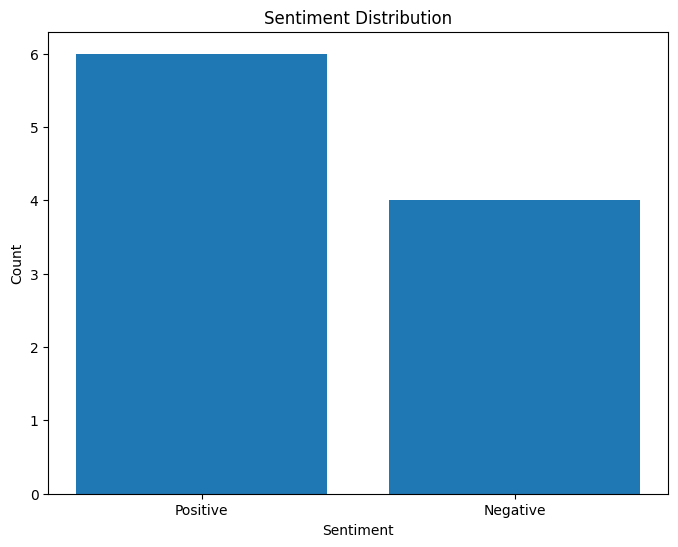

In [11]:
sentiment_counts = df['Sentiment'].value_counts()
plt.figure(figsize=(8, 6))
plt.bar(sentiment_counts.index, sentiment_counts.values)
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.title('Sentiment Distribution')
plt.show()

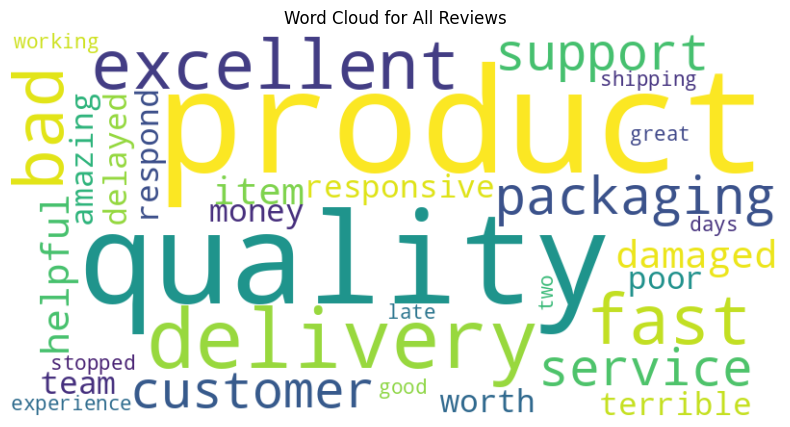

In [13]:
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_words)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for All Reviews')
plt.show()

In [14]:
print("\nBusiness Insights")
print("----------------------")
positive_count = len(df[df['Sentiment'] == 'Positive'])
negative_count = len(df[df['Sentiment'] == 'Negative'])
print("Total Positive Reviews: ", positive_count)
print("Total Negative Reviews: ", negative_count)

print("\nCommon Positive Areas:")
print("- Product Quality")
print("- Fast Delivery")
print("- Good customer service")

print("\nCommon Negative Areas:")
print("- Poor product quality")
print("- Delayed delivery")
print("- Poor customer service")


Business Insights
----------------------
Total Positive Reviews:  6
Total Negative Reviews:  4

Common Positive Areas:
- Product Quality
- Fast Delivery
- Good customer service

Common Negative Areas:
- Poor product quality
- Delayed delivery
- Poor customer service
